#     COURSE: Linear algebra: theory and implementation
##    SECTION: Singular value decomposition

#### Instructor: sincxpress.com
##### Course url: https://www.udemy.com/course/linear-algebra-theory-and-implementation/?couponCode=202110

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.signal
from numpy import linalg as LA
from rich import print
from rich.console import Console
from scipy import linalg as SLA
from sklearn.datasets import fetch_openml, make_classification

console = Console()


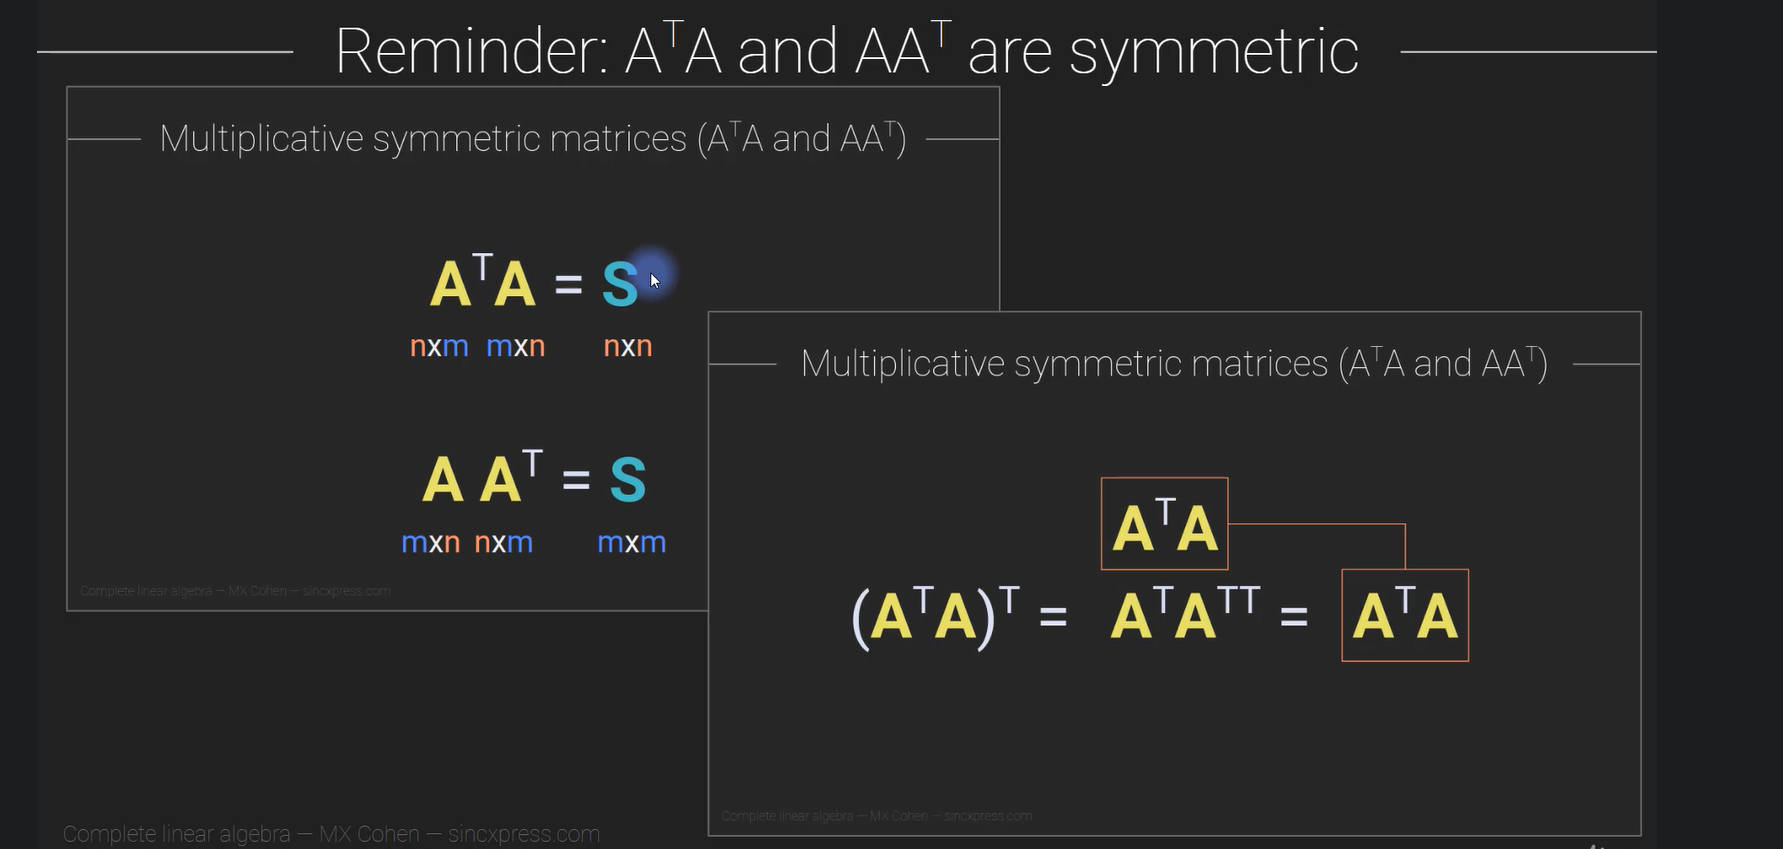

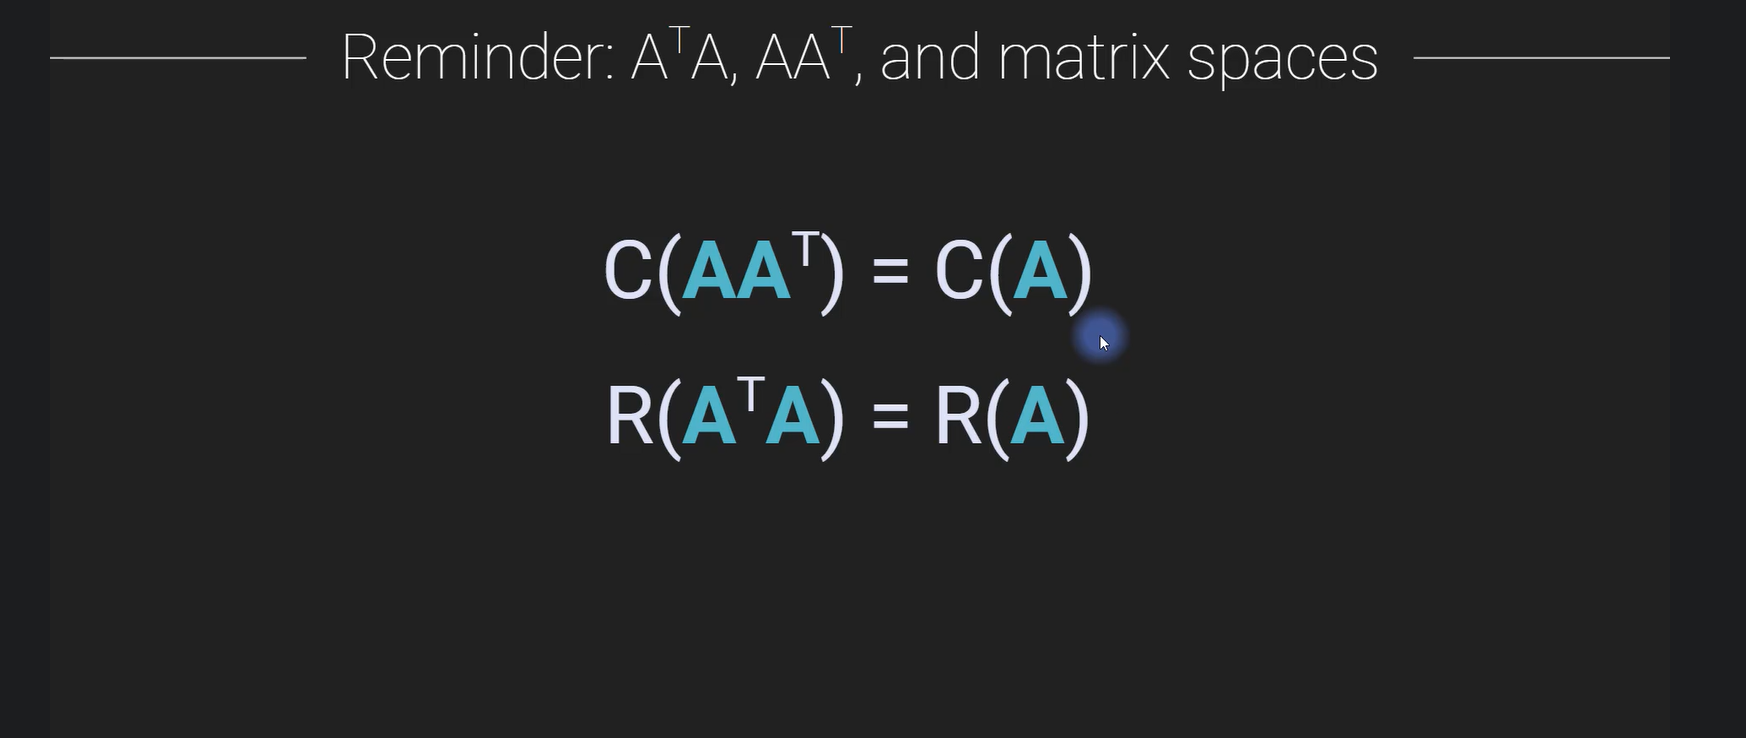


---
# VIDEO: Singular value decomposition
---


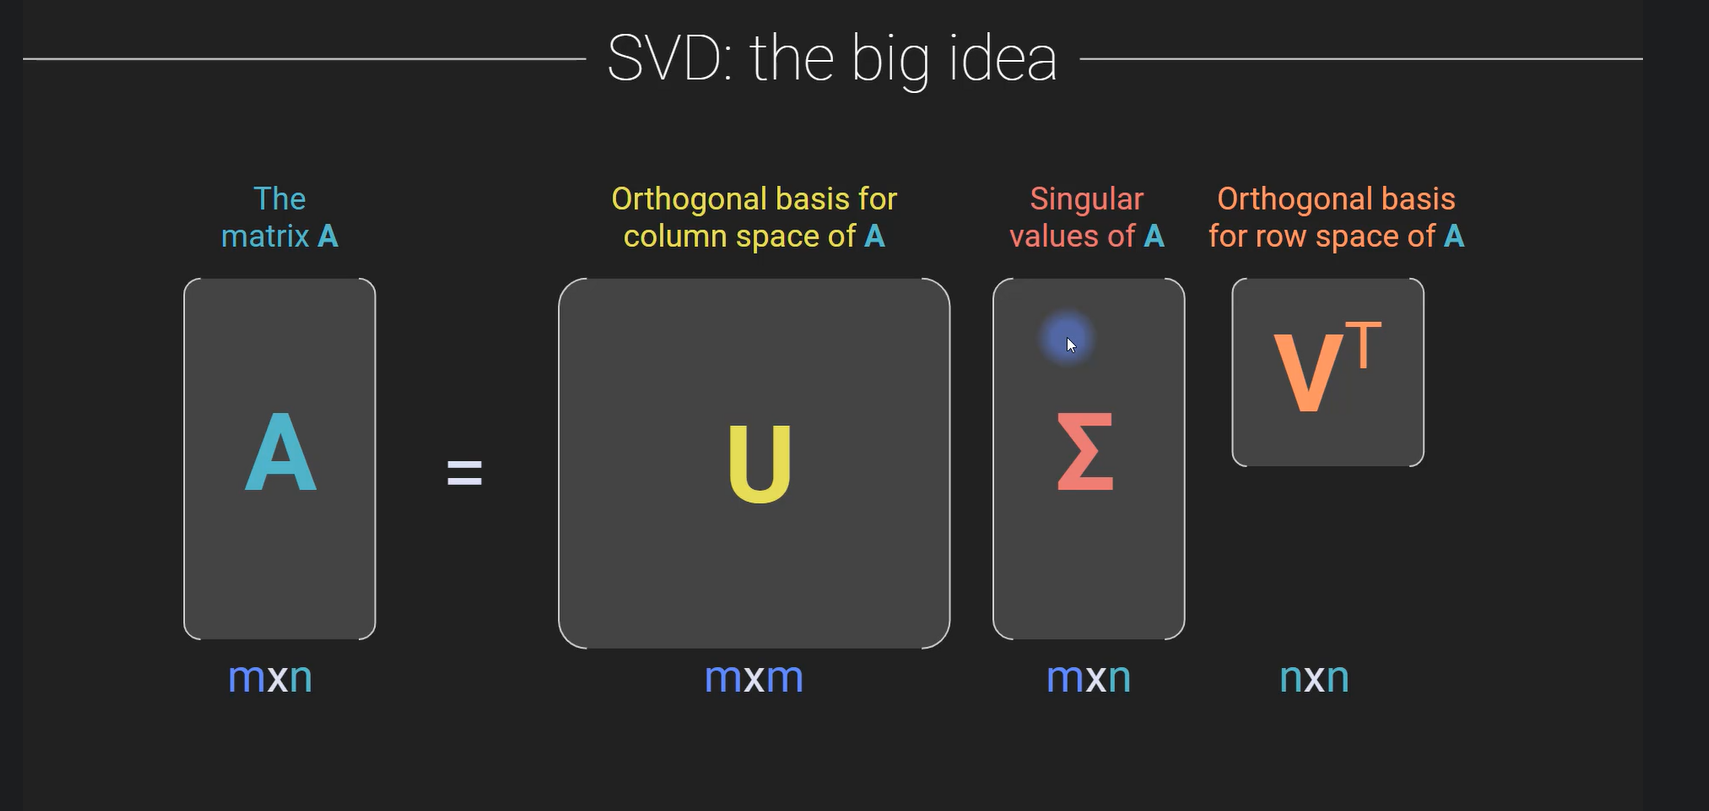

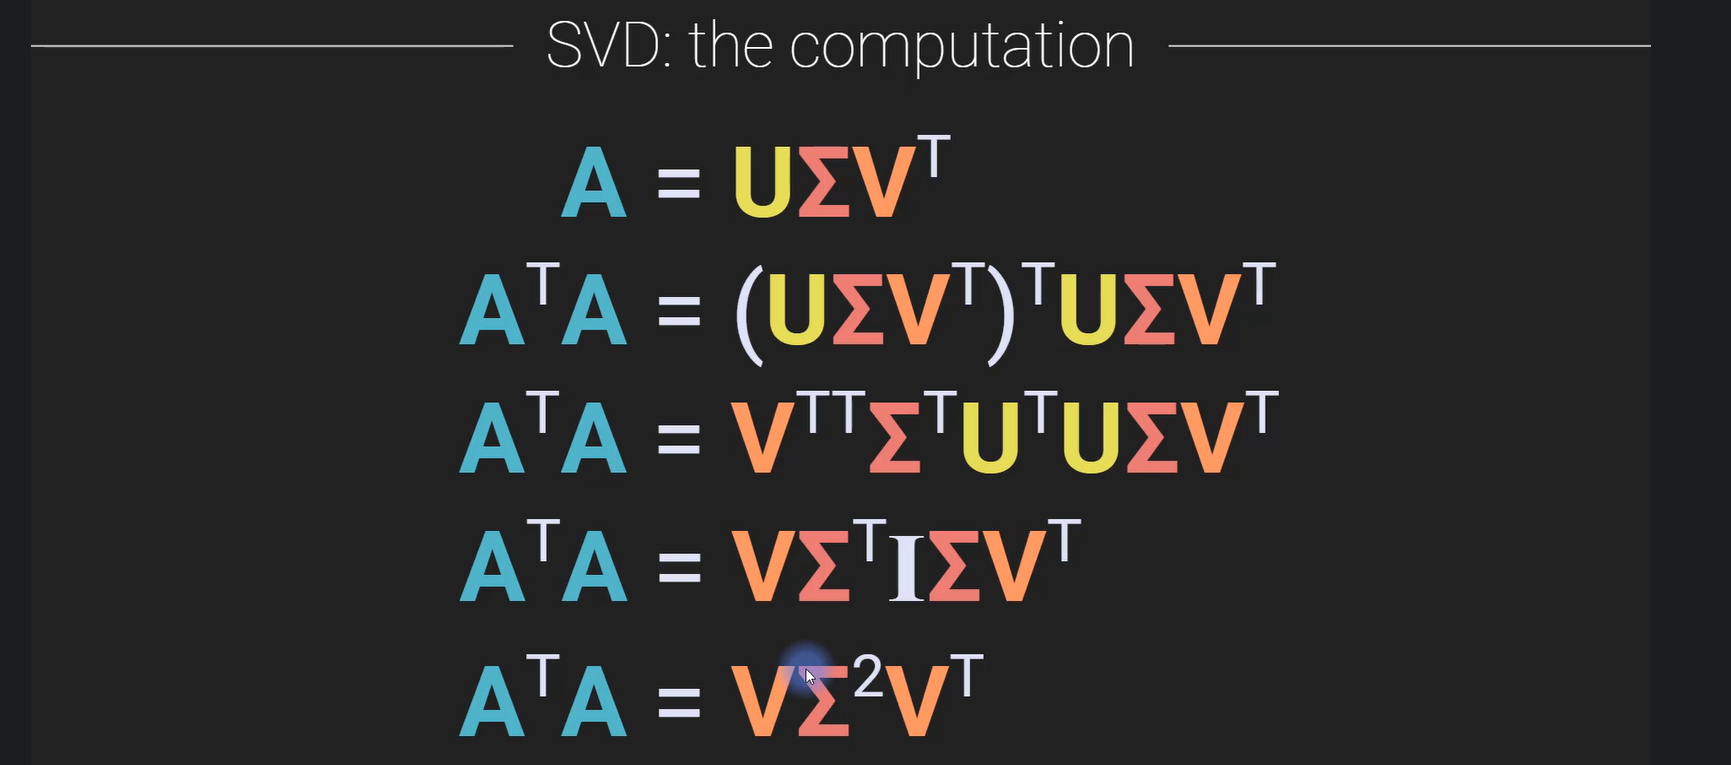

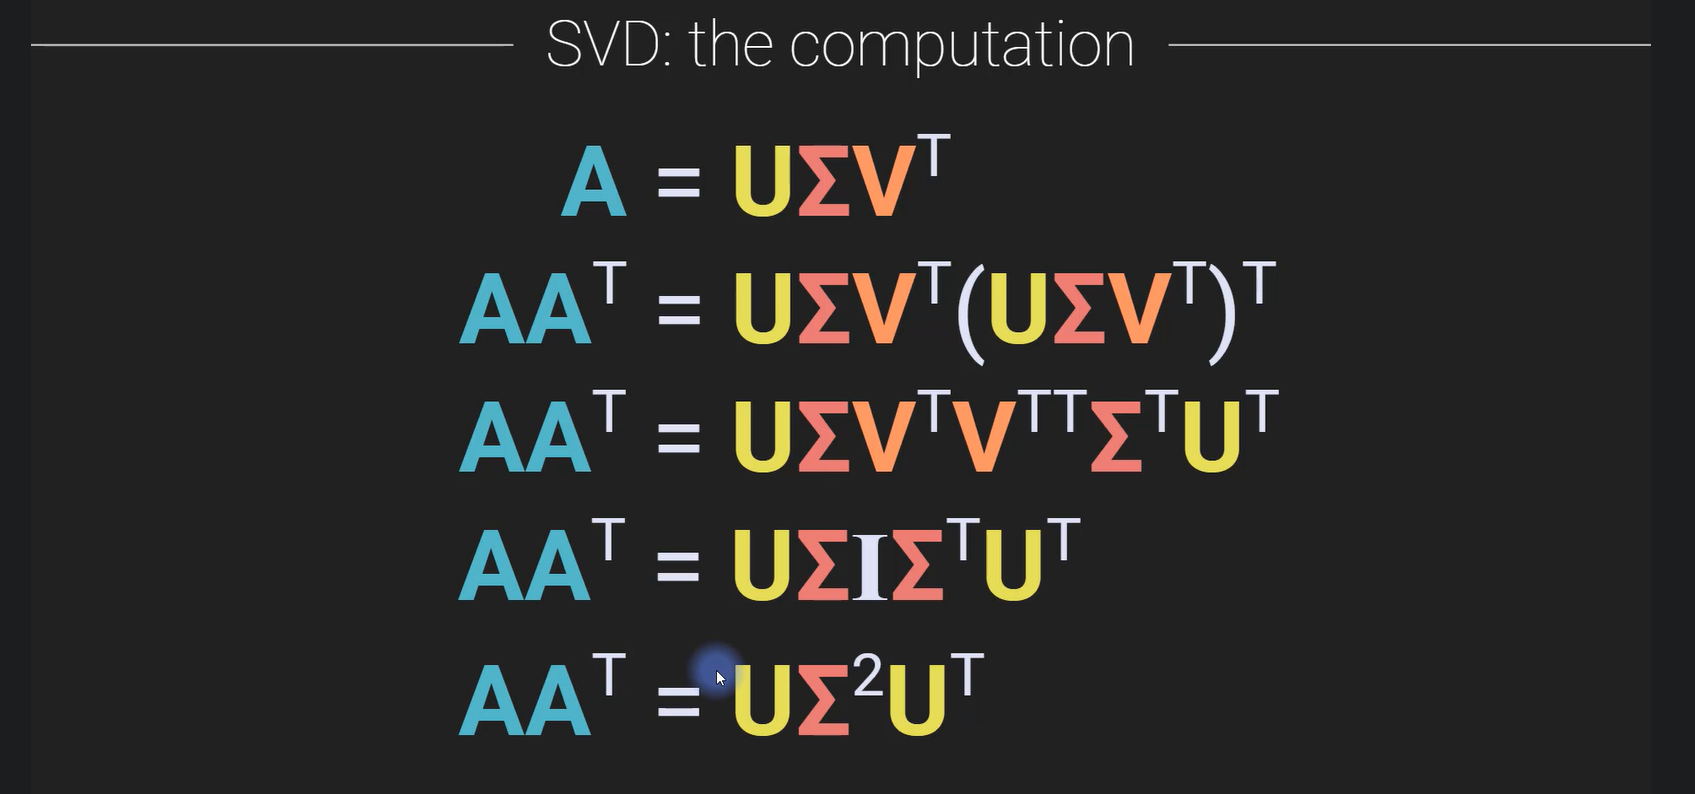

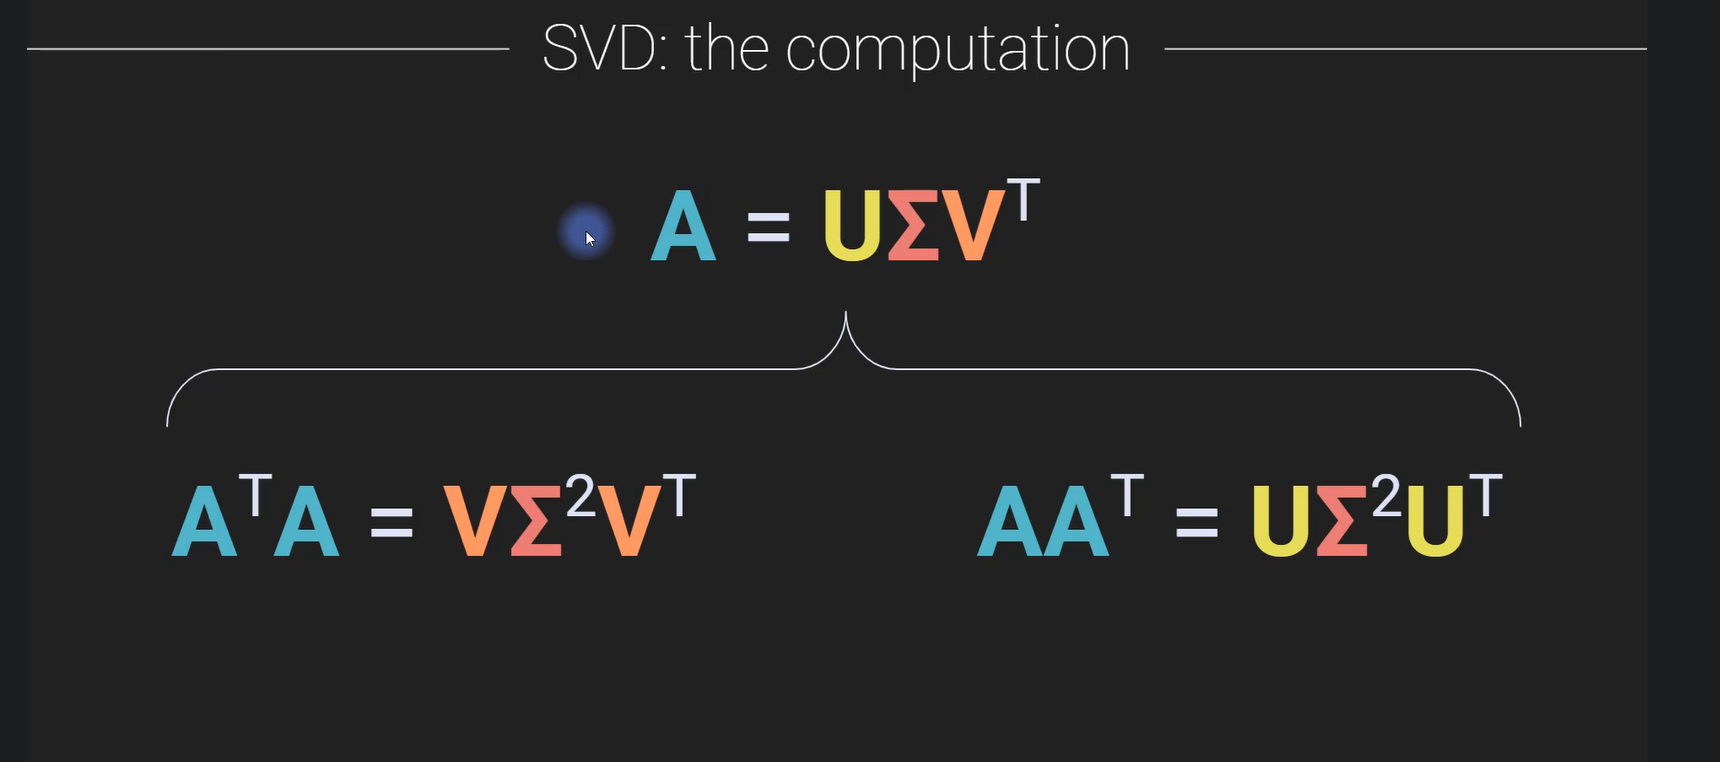

In [27]:
steel_X: pd.DataFrame
steel_y: pd.Series

steel_X, steel_y = fetch_openml(data_id=1504, as_frame=True, return_X_y=True)

steel_at_a = steel_X.T @ steel_X
steel_a_at = steel_X @ steel_X.T

eigval_at_a, eigvec_at_a = LA.eig(steel_at_a)
eigval_a_at, eigvec_a_at = LA.eig(steel_a_at)

# 1. Sort A.T @ A results (V and Sigma)
idx_v = np.argsort(eigval_at_a)[::-1]
eigval_at_a = eigval_at_a[idx_v]
eigvec_at_a = eigvec_at_a[:, idx_v]

# 2. Sort A @ A.T results (U)
idx_u = np.argsort(eigval_a_at)[::-1]
eigval_a_at = eigval_a_at[idx_u]
eigvec_a_at = eigvec_a_at[:, idx_u]

# 3. Fill Sigma with square roots
Sigma = np.zeros(steel_X.shape)
np.fill_diagonal(Sigma, np.sqrt(np.maximum(eigval_at_a, 0)))


/home/dev/work/LinAlgCourse/.venv/lib/python3.13/site-packages/numpy/lib/_index_tricks_impl.py:923: ComplexWarning: Casting complex values to real discards the imaginary part
  a.flat[:end:step] = val


## Why Independent Eigendecomposition Needs Sign Alignment


### 1. The Core Definition of SVD
In Singular Value Decomposition, the left singular vectors $\mathbf{u}_k$, singular values $\sigma_k$, and right singular vectors $\mathbf{v}_k$ are coupled by the transformation:

$$A \mathbf{v}_k = \sigma_k \mathbf{u}_k$$

Since singular values are strictly non-negative ($\sigma_k > 0$), this means:
- The vector $A \mathbf{v}_k$ and the vector $\mathbf{u}_k$ **must point in the exact same direction**.

---

### 2. The Eigenvector "Sign Ambiguity" Problem
By definition, if $\mathbf{v}$ is an eigenvector of a symmetric matrix $M$:

$$M \mathbf{v} = \lambda \mathbf{v}$$

Notice what happens if we negate $\mathbf{v}$:

$$M (-\mathbf{v}) = -(M \mathbf{v}) = -(\lambda \mathbf{v}) = \lambda (-\mathbf{v})$$

Both $+\mathbf{v}$ and $-\mathbf{v}$ are **equally valid unit eigenvectors**. Any eigenvalue solver (`np.linalg.eig` or `eigh`) arbitrarily picks one of those two directions.

---

### 3. What Happens When Solved Independently?

When you run:
1. `eigvec_at_a` $\implies$ solver picks a sign for $\mathbf{v}_k$ (either $+\mathbf{v}_k$ or $-\mathbf{v}_k$).
2. `eigvec_a_at` $\implies$ solver picks a sign for $\mathbf{u}_k$ (either $+\mathbf{u}_k$ or $-\mathbf{u}_k$).

Because the two solver calls know nothing about each other:
- There is a 50% chance for each component $k$ that $\mathbf{u}_k$ points in the **opposite direction** of $A \mathbf{v}_k$.
- When they point in opposite directions:
  $$A \mathbf{v}_k = -\sigma_k \mathbf{u}_k$$
- This injects a hidden negative sign into that rank-1 component: $-\sigma_k \mathbf{u}_k \mathbf{v}_k^T$ instead of $+\sigma_k \mathbf{u}_k \mathbf{v}_k^T$, destroying the sum when reconstructing $A$.

---

### 4. Step-by-Step Code Walkthrough

Here is the exact breakdown of the loop:

```python
for k in range(33):
    # STEP 1: Ignore zero singular values (null space / noise)
    if sigma[k] > 1e-10:
        
        # STEP 2: Transform v_k using matrix A
        # According to SVD: (A @ v_k) should be a positive scalar multiple of u_k
        transformed_v = A @ eigvec_at_a[:, k]
        
        # STEP 3: Check directional alignment using the Dot Product
        # dot(x, y) = ||x|| ||y|| cos(theta)
        # - If theta = 0 deg (same direction)    -> dot > 0
        # - If theta = 180 deg (opposite direction) -> dot < 0
        alignment = np.dot(transformed_v, eigvec_a_at[:, k])
        
        # STEP 4: If pointing backwards, flip u_k to face forward
        if alignment < 0:
            eigvec_a_at[:, k] *= -1
```

---

### 5. Why Standard SVD Implementations Skip This Loop

Notice in Step 2:
$$A \mathbf{v}_k = \sigma_k \mathbf{u}_k \implies \mathbf{u}_k = \frac{1}{\sigma_k} A \mathbf{v}_k$$

If you compute $\mathbf{u}_k$ **directly from $\mathbf{v}_k$** using $\mathbf{u}_k = \frac{A \mathbf{v}_k}{\sigma_k}$, you never have to solve $A A^T$, and $\mathbf{u}_k$ is **guaranteed to inherit the correct sign automatically**.

## Which Sigma should be used? From A.T @ A or A @ A.T

### 1. The Non-Zero Eigenvalues are Identical

For any matrix $A$ of shape $m \times n$ (with $m = 1941, n = 33$):
- $A^T A$ is $33 \times 33$ $\implies$ has **33 eigenvalues**.
- $A A^T$ is $1941 \times 1941$ $\implies$ has **1941 eigenvalues**.

However:
- The **top 33 eigenvalues** of $A A^T$ and $A^T A$ are **mathematically identical**.
- The remaining $1941 - 33 = 1908$ eigenvalues of $A A^T$ are **all exactly zero**.

So non-trivially, there are only **33 singular values** $\sigma_1, \sigma_2, \dots, \sigma_{33}$.

---

### 2. Why the Diagram Shows $\Sigma$ Matching Both

In theoretical Full SVD:
$$A_{(1941 \times 33)} = U_{(1941 \times 1941)} \, \Sigma_{(1941 \times 33)} \, V^T_{(33 \times 33)}$$

$\Sigma$ is an **$m \times n$ ($1941 \times 33$) rectangular matrix** structured as:


$$\Sigma = \begin{bmatrix}
\sigma_1 & 0 & \dots & 0 \\
0 & \sigma_2 & \dots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \dots & \sigma_{33} \\
0 & 0 & \dots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \dots & 0
\end{bmatrix} = \begin{bmatrix} \Sigma_{33 \times 33} \\ \mathbf{0}_{1908 \times 33} \end{bmatrix}$$

---

### Matrix Shape Breakdown

In Full SVD:

$$A = U \, \Sigma \, V^T$$

$$(1941 \times 33) = (1941 \times 1941) \times (1941 \times 33) \times (33 \times 33)$$

- **$\Sigma_{33 \times 33}$**: The top $33 \times 33$ diagonal submatrix containing the singular values $\sigma_1, \sigma_2, \dots, \sigma_{33}$.
- **$\mathbf{0}_{1908 \times 33}$**: The bottom $1908 \times 33$ submatrix of all zeros corresponding to the extra dimensions from $U$.

- The non-zero entries on the diagonal are the 33 positive values from $\sqrt{\lambda_i}$.
- The bottom $1908 \times 33$ block is all zeros, which corresponds to the 1908 zero eigenvalues of $A A^T$.

---

### 3. Which $\Sigma$ Should You Use?

Always compute $\Sigma$ from **$A^T A$** (the smaller $33 \times 33$ matrix), because:

1. **Efficiency:** Eigendecomposing $33 \times 33$ takes $< 1\text{ ms}$, while $1941 \times 1941$ is computationally heavy and suffers from numerical precision errors on the zero eigenvalues.
2. **Construction in Python:**

```python
# Compute 33 singular values from A.T @ A
evals_V, V = np.linalg.eigh(steel_X.T @ steel_X)
# Sort descending
idx = np.argsort(evals_V)[::-1]
singular_values = np.sqrt(np.maximum(evals_V[idx], 0))  # shape (33,)

# Option A: Full SVD Sigma matrix (1941 x 33)
Sigma_full = np.zeros(steel_X.shape)                    # (1941, 33)
np.fill_diagonal(Sigma_full, singular_values)

# Option B: Economy / Compact SVD (33 x 33) -- preferred
Sigma_econ = np.diag(singular_values)                   # (33, 33)
```

## The transpose of a matrix product reverses the order



$$(A B)^T = B^T A^T$$

For a chain of three or more matrices:

$$(A B C)^T = C^T B^T A^T$$

$$(U \Sigma V^T)^T = (V^T)^T \Sigma^T U^T = V \Sigma^T U^T$$

---

### Why the Order Reverses

#### 1. The "Shoes and Socks" Intuition
Think of multiplying matrices like putting on socks, then shoes:
- **Operation:** $\text{Shoes}(\text{Socks})$
- **To reverse the process (transpose/inverse):** You must take off your shoes first, then your socks:
  $$(\text{Socks} \cdot \text{Shoes})^T = \text{Shoes}^T \cdot \text{Socks}^T$$

#### 2. Dimension Matching
If $A$ has shape $m \times k$ and $B$ has shape $k \times n$:
- The product $AB$ has shape $m \times n$.
- Therefore, $(AB)^T$ must have shape **$n \times m$**.

Now check the transposes:
- $A^T$ has shape $k \times m$
- $B^T$ has shape $n \times k$

You cannot multiply $A^T B^T$ because inner dimensions $(m \neq n)$ don't match!  
The only valid multiplication is:
$$B^T A^T \quad \longrightarrow \quad (n \times k) \times (k \times m) = (n \times m)$$

---

### Completing the Simplification in the Slide

Following the third line from the slide:

$$A^T A = \underbrace{V^{TT}}_{V} \Sigma^T \underbrace{U^T U}_{I} \Sigma V^T$$

Since $U$ is an orthogonal matrix ($U^T U = I$), and $\Sigma$ is diagonal ($\Sigma^T = \Sigma$):

$$A^T A = V \Sigma^2 V^T$$

This proves that:
- The right singular vectors $V$ from SVD are the **eigenvectors of $A^T A$**.
- The singular values $\sigma_i$ are the **square roots of the eigenvalues of $A^T A$** ($\sigma_i = \sqrt{\lambda_i}$).

You are completely right. $A^T A = V \Sigma^2 V^T$ is the eigendecomposition of $A^T A$, **not** $A$.

However, this is the exact bridge that allows us to find the SVD of $A = U \Sigma V^T$ itself. Here is how $A^T A$ and $A A^T$ give you all three pieces ($U$, $\Sigma$, and $V$) of the matrix $A$:

---

### Step 1: Get $V$ and $\Sigma$ from $A^T A$
Eigendecompose the symmetric matrix $A^T A$:
$$A^T A = V \Lambda V^T$$
- **Right Singular Vectors ($V$):** The eigenvectors of $A^T A$.
- **Singular Values ($\Sigma$):** The square roots of the eigenvalues:
  $$\sigma_i = \sqrt{\lambda_i}$$

---

### Step 2: Get $U$ from $A A^T$ (or directly from $A V$)
Now we just need $U$ (the left singular vectors). There are two equivalent ways to get it:

#### Method A: From $A A^T$
If you do the same trick in reverse:
$$A A^T = (U \Sigma V^T)(U \Sigma V^T)^T = U \Sigma \underbrace{V^T V}_{I} \Sigma^T U^T = U \Sigma^2 U^T$$
- **Left Singular Vectors ($U$):** The eigenvectors of $A A^T$.

#### Method B: Directly mapping $V$ through $A$
Since $A = U \Sigma V^T$, multiplying by $V$ on the right gives:
$$A V = U \Sigma \implies A v_i = \sigma_i u_i$$
So each column $u_i$ of $U$ is just:
$$u_i = \frac{1}{\sigma_i} A v_i$$

---

### Step 3: Put Them Together to Reconstruct $A$
Now that you have computed $U$, $\Sigma$, and $V$, you reassemble them into the original matrix $A$:
$$A = U \Sigma V^T$$

---

### Summary in Code

```python
import numpy as np

# A can be any matrix (even rectangular)
A = np.random.randn(4, 3)

# 1. Eigendecomposition of A.T @ A gives V and Sigma
evals_V, V = np.linalg.eigh(A.T @ A)

# Sort descending (eig returns ascending by default)
idx = np.argsort(evals_V)[::-1]
evals_V = evals_V[idx]
V = V[:, idx]

sigma = np.sqrt(np.maximum(evals_V, 0))  # singular values

# 2. Eigendecomposition of A @ A.T gives U
evals_U, U = np.linalg.eigh(A @ A.T)
idx_U = np.argsort(evals_U)[::-1]
U = U[:, idx_U]

# Sign alignment: ensure A @ v_i = sigma_i * u_i
for i in range(len(sigma)):
    if sigma[i] > 1e-10:
        if np.dot(A @ V[:, i], U[:, i]) < 0:
            U[:, i] *= -1

# 3. Form Sigma matrix and reconstruct original A
Sigma_mat = np.zeros(A.shape)
np.fill_diagonal(Sigma_mat, sigma)

A_reconstructed = U @ Sigma_mat @ V.T
print("Matches original A:", np.allclose(A, A_reconstructed))
```

In [13]:
# the matrix
A = [[3, 0, 5], [8, 1, 3]]

# Note differences from MATLAB: S is vector, V is V'
U, S, V = np.linalg.svd(A)

print(U), print(" ")
print(S), print(" ")
print(V)

[[-0.52138438 -0.85332193]
 [-0.85332193  0.52138438]]

[9.89086518 3.18916698]

[[-0.84833111 -0.08627374 -0.52238986]
 [ 0.50518185  0.16348607 -0.84738634]
 [-0.15851066  0.98276607  0.09510639]]

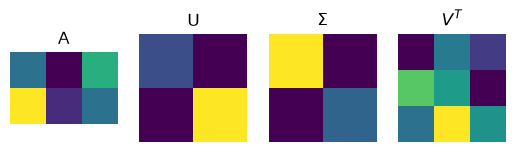

In [14]:
plt.subplot(141)
plt.imshow(A)
plt.title("A")
plt.axis("off")

plt.subplot(142)
plt.imshow(U)
plt.title("U")
plt.axis("off")

plt.subplot(143)
plt.imshow(np.diag(S))
plt.title(r"$\Sigma$")
plt.axis("off")

plt.subplot(144)
plt.imshow(V)
plt.title("$V^T$")
plt.axis("off")

plt.show()

In [15]:
M = np.random.randn(5, 5)

A = M + M.T


In [16]:
eigenvalues, eigenvectors = LA.eig(A)
U, s, V = LA.svd(A)

In [17]:
print(np.sort_complex(eigenvalues))
print(np.sort_complex(s))

[-4.44210691+0.j -0.56606727+0.j  0.85608273+0.j  2.1691183 +0.j
  4.60630669+0.j]

[0.56606727+0.j 0.85608273+0.j 2.1691183 +0.j 4.44210691+0.j
 4.60630669+0.j]

1. **Singular values $\sigma_i$ are ALWAYS non-negative real numbers ($\sigma_i \ge 0$).**
2. **Eigenvalues $\lambda_i$ of a symmetric matrix are real, but can be positive, negative, or zero.**

For any real symmetric matrix $A = A^T$, the singular values are the **absolute values** (magnitudes) of the eigenvalues:

$$\sigma_i = |\lambda_i|$$

---

### Why this happens mathematically

Recall how singular values relate to $A^T A$:
$$\sigma_i = \sqrt{\lambda_i(A^T A)}$$

For a symmetric matrix ($A = A^T$):
$$A^T A = A^2$$

Since the eigenvalues of $A^2$ are $\lambda_i^2$:
$$\sigma_i = \sqrt{\lambda_i^2} = |\lambda_i|$$

Whenever an eigenvalue $\lambda_i$ is **negative**, the SVD absorbs the minus sign into one of the singular vectors ($U$ or $V$) so that $\sigma_i$ stays strictly positive:

$$A v_i = \lambda_i v_i = (-|\lambda_i|) v_i = |\lambda_i| (-v_i) = \sigma_i u_i \quad (\text{where } u_i = -v_i)$$

---

### How to Verify in Python

Take `np.abs(eigenvalues)` and sort them:

```python
# Singular values equal the absolute values of the eigenvalues
print("Matches absolute values:", np.allclose(np.sort(np.abs(eigenvalues)), np.sort(s)))
# Returns: True


# VIDEO: Relation between singular values and eigenvalues

In [ ]:
# case 1: eig(A'A) vs. svd(A)

A = np.array([ [3,1,0], [1,1,0] ])

print( np.sort(np.linalg.eig(A.T@A)[0]) )
print( np.sort(np.linalg.svd(A)[1])**2 )

In [ ]:
# case 2: eig(A'A) vs. svd(A'A)

print(np.sort(np.linalg.eig(A.T@A)[0]))
print(np.sort(np.linalg.svd(A.T@A)[1]))

In [ ]:
# case 3a: eig(A) vs. svd(A), real-valued eigs

# need a square matrix for eig
A = [ [3,1,0], [1,1,0], [1,1,1]]

print(np.sort(np.linalg.eig(A)[0]))
print(np.sort(np.linalg.svd(A)[1]))

In [ ]:
# case 3b: eig(A) vs. svd(A), complex eigs

# random matrices are likely to give complex eigenvalues
A = np.random.randn(3,3)

print(np.sort(np.linalg.eig(A)[0]))
print(np.sort(np.linalg.svd(A)[1]))


---
# VIDEO: Spectral theory of matrices
---


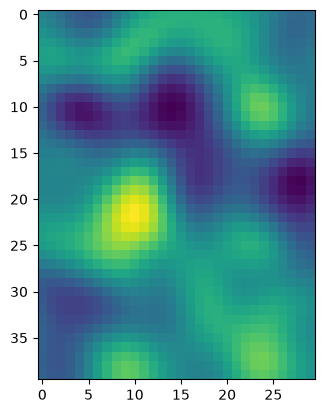

In [24]:
# matrix sizes
m = 40
n = 30

# define a 2D Gaussian for smoothing
k = int((m + n) / 4)
xx = np.linspace(-3, 3, k)
[X, Y] = np.meshgrid(xx, xx)
g2d = np.exp(-(X**2 + Y**2) / (k / 8))

# matrix
A = scipy.signal.convolve2d(np.random.randn(m, n), g2d, "same")

plt.imshow(A)
plt.show()

<>:18: SyntaxWarning: invalid escape sequence '\S'
<>:27: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\S'
<>:27: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_723470/1654317067.py:18: SyntaxWarning: invalid escape sequence '\S'
  plt.title("$\Sigma$")
/tmp/ipykernel_723470/1654317067.py:27: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel("$\sigma$")


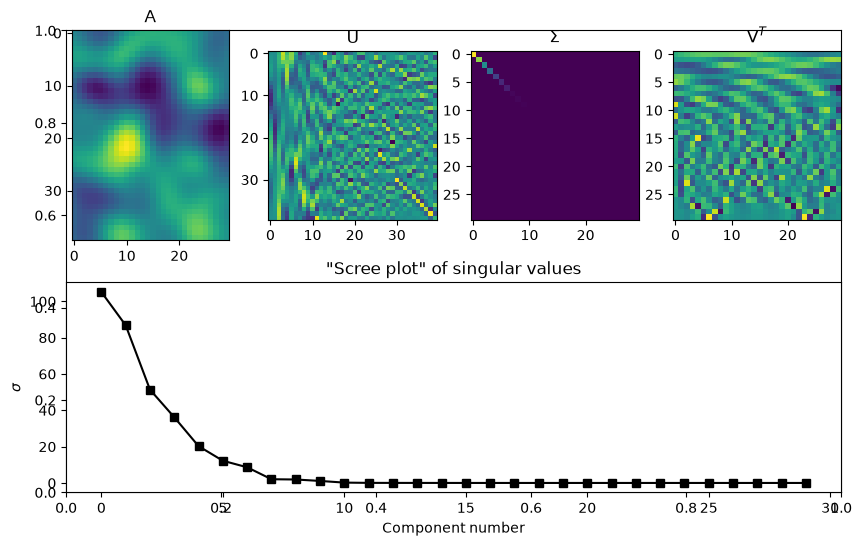

In [25]:
# SVD (remember that V comes out transposed)
U, S, V = np.linalg.svd(A)


# show the constituent matrices
fig = plt.subplots(1, figsize=(10, 6))

plt.subplot(241)
plt.imshow(A)
plt.title("A")

plt.subplot(242)
plt.imshow(U)
plt.title("U")

plt.subplot(243)
plt.imshow(np.diag(S))
plt.title("$\Sigma$")

plt.subplot(244)
plt.imshow(V)
plt.title("V$^T$")

plt.subplot(212)
plt.plot(S, "ks-")
plt.xlabel("Component number")
plt.ylabel("$\sigma$")
plt.title('"Scree plot" of singular values')

plt.show()

In [ ]:
rank1mats = np.zeros((5,m,n))

for i in range(0,5):
    
    # create rank1 matrix
    rank1mats[i,:,:] = np.outer( U[:,i]*S[i],V[i,:] )
    
    plt.subplot2grid((2,5),(0,i))
    plt.imshow(rank1mats[i,:,:],vmin=-5,vmax=5)
    plt.axis('off')
    plt.title('C.%d' %(i+1))
    
    plt.subplot2grid((2,5),(1,i))
    imdat = np.sum(rank1mats[:i+1,:,:],axis=0)
    plt.imshow(imdat,vmin=-5,vmax=5)
    plt.axis('off')
    plt.title('Cs 1:%d' %(i+1))

plt.show()

# then show the original
plt.imshow(A,vmin=-5,vmax=5)
plt.show()


---
# VIDEO: SVD for low-rank approximations
---


In [ ]:
# number of components (singular "layers") to keep
nComps = 5

# reduced matrices
Ur = U[:,0:nComps]
Sr = S[0:nComps]
Vr = V[0:nComps,:]

# low-rank apporoximation
reconImage = Ur@np.diag(Sr)@Vr

# rank (confirm same as nComps)
print( 'rank =',np.linalg.matrix_rank(reconImage) )

In [ ]:
# error map and percent difference from original matrix
errormap = (reconImage-A)**2

# show the results!
plt.subplot(131)
plt.imshow(A)
plt.axis('off')
plt.title('Original')

plt.subplot(132)
plt.imshow(reconImage)
plt.axis('off')
plt.title('Low-rank')

plt.subplot(133)
plt.imshow(errormap,vmin=-1,vmax=1)
plt.axis('off')
plt.title('error')
plt.show()



---
# VIDEO: Convert singular values to percent variance
---


In [ ]:
# matrix sizes
m = 40
n = 30

# define a 2D Gaussian for smoothing
k = int( (m+n)/4 )
xx = np.linspace(-3,3,k)
[X,Y] = np.meshgrid(xx,xx)
g2d = np.exp(-(X**2 + Y**2) / (k/8))

# matrix
A = scipy.signal.convolve2d(np.random.randn(m,n),g2d,'same')

In [ ]:
Ascaled = A*1

# SVD
U,s,V = np.linalg.svd(Ascaled)

# convert to percent variance
spct = 100*s/np.sum(s)

# plot the singular values for comparison
fig = plt.subplots(1,figsize=(7,5))

plt.subplot(211)
plt.plot(s,'ks-')
plt.xlabel('Component number')
plt.ylabel('$\sigma$')
plt.title('Raw singular values')

plt.subplot(212)
plt.plot(spct,'ks-')
plt.xlabel('Component number')
plt.ylabel('$\sigma$ (% of total)')
plt.title('Percent-change-normalized singular values')

plt.tight_layout()
plt.show()


---
# VIDEO: SVD, matrix inverse, and pseudoinverse
---


In [ ]:

# the matrix
A = [ [1,2,3],
      [1,2,4], # hint: change 2->0 for invertible matrix to test
      [1,2,5]  ]
  
# SVD
U,S,V = np.linalg.svd(A)

# pseudoinvert S
nonzeroels = S>10**-14 # find nonzero elements (>rounding errors)
S[nonzeroels] = 1/S[nonzeroels] # invert only those elements

# now pseudoinvert A
Ai = V.T@np.diag(S)@U.T

# it's sortof close to I...?
print( Ai@A ), print(' ')

# compute with pinv function
print( np.linalg.pinv(A)@A )


In [ ]:
import inspect
lines = inspect.getsource(np.linalg.pinv)
print(lines)


---
# VIDEO: Condition number of a matrix
---


In [ ]:

# matrix sizes
m = 40

# define a 2D Gaussian for smoothing
k = int( (m+n)/4 )
xx = np.linspace(-3,3,k)
[X,Y] = np.meshgrid(xx,xx)
g2d = np.exp(-(X**2 + Y**2) / (k/8))

# matrix
A = np.random.randn(m,m)
A = scipy.signal.convolve2d(A,g2d,'same')



# SVD
S = np.linalg.svd(A)[1]

# compute condition number
condnum = S[0]/S[-1]
print(S[0],S[-1])

# show the matrix
plt.subplot(211)
plt.imshow(A)
plt.axis('off')
plt.title('Cond.num: %d' %condnum)

plt.subplot(212)
plt.plot(S,'ks-')
plt.xlabel('Component number')
plt.ylabel('$\sigma$')
plt.title('"Scree plot" of singular values')

plt.show()

In [ ]:
## sphere

# the transformation matrix T
T = np.eye(3)
T[-1,-1] = .5


fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# Make data
n = 21
u = np.linspace(0, 2*np.pi,n)
v = np.linspace(0, np.pi,n)
x = np.outer(np.cos(u), np.sin(v))
y = np.outer(np.sin(u), np.sin(v))
z = np.outer(np.ones(np.size(u)), np.cos(v))

# put coords in a matrix to be transformed
M = np.concatenate( (np.reshape(x,(n*n,1)),np.reshape(y,(n*n,1)),np.reshape(z,(n*n,1))) ,axis=1)

# apply the transformation matrix to the coordinates
TM = T@M.T

# get out the new coordinates
xp = np.reshape(TM[0,:],(n,n))
yp = np.reshape(TM[1,:],(n,n))
zp = np.reshape(TM[2,:],(n,n))

# Plot the surface
ax.plot_surface(xp,yp,zp, color='b')
ax.axis('square')
ax.set_xlim3d(-1,1)
ax.set_ylim3d(-1,1)
ax.set_zlim3d(-1,1)

plt.show()